In [ ]:
from huggingface_hub import login
login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


# Importing the models

In [ ]:
import os
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import string
import re
import numpy as np
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import seaborn as sns
import json
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print(f"TensorFlow Version: {tf.__version__}")
gpu = len(tf.config.list_physical_devices('GPU')) > 0
print("GPU is", "AVAILABLE" if gpu else "NOT AVAILABLE")

TensorFlow Version: 2.19.0
GPU is AVAILABLE


# Data preprocessing

In [ ]:
# PART 1:  PREPROCESSING


class DataPreprocessor:
    def __init__(self):
        self.preprocessing_log = []
        self.stats = {}

    def log_step(self, step_name, details):
        self.preprocessing_log.append({
            'step': step_name,
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'details': details
        })
        print(f"  \u2713 {step_name}")

    def clean_text(self, text, text_type="source"):
        text = str(text)
        text = re.sub(r'<.*?>', '', text)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'\S+@\S+', '', text)

        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"
            u"\U0001F300-\U0001F5FF"
            u"\U0001F680-\U0001F6FF"
            u"\U0001F1E0-\U0001F1FF"
            u"\U00002702-\U000027B0"
            u"\U000024C2-\U0001F251"
            "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        contractions = {
            r"won't": "will not", r"can't": "cannot", r"n't": " not",
            r"'re": " are", r"'s": " is", r"'d": " would",
            r"'ll": " will", r"'t": " not", r"'ve": " have", r"'m": " am"
        }
        for pattern, replacement in contractions.items():
            text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def normalize_text(self, text):
        import unicodedata
        text = text.lower()
        text = re.sub(r'\d+', '<NUM>', text)
        text = unicodedata.normalize('NFKD', text).encode('ASCII', 'ignore').decode('ASCII')
        text = re.sub(r'[""]', '"', text)
        text = re.sub(r"['\u2019]", "'", text)
        text = re.sub(r'[^\w\s<>"\']', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text

    def analyze_dataset(self, df, source_col, target_col):

        print("DATASET ANALYSIS")


        analysis = {
            'total_samples': len(df),
            'source_stats': {
                'avg_length': df[source_col].str.len().mean(),
                'max_length': df[source_col].str.len().max(),
                'min_length': df[source_col].str.len().min(),
                'unique_words': len(set(' '.join(df[source_col]).split())),
            },
            'target_stats': {
                'avg_length': df[target_col].str.len().mean(),
                'max_length': df[target_col].str.len().max(),
                'min_length': df[target_col].str.len().min(),
                'unique_words': len(set(' '.join(df[target_col]).split())),
            },
            'missing_values': {
                'source': df[source_col].isnull().sum(),
                'target': df[target_col].isnull().sum()
            },
            'duplicates': df.duplicated().sum()
        }

        print(f"  Total samples: {analysis['total_samples']}")
        print(f"  Duplicates: {analysis['duplicates']}")
        print(f"  Source avg length: {analysis['source_stats']['avg_length']:.1f} chars")
        print(f"  Target avg length: {analysis['target_stats']['avg_length']:.1f} chars")
        return analysis

    def prepare_data(self, df, source_col, target_col):
        print("PREPROCESSING PIPELINE")


        initial_analysis = self.analyze_dataset(df, source_col, target_col)
        self.stats['initial'] = initial_analysis

        print("\n Step 1: Handling missing values...")
        missing_source = df[source_col].isnull().sum()
        missing_target = df[target_col].isnull().sum()
        df = df.dropna(subset=[source_col, target_col])
        self.log_step('missing_value_handling', {
            'missing_source_removed': int(missing_source),
            'missing_target_removed': int(missing_target)
        })

        print("\n Step 2: Removing duplicates...")
        duplicate_count = df.duplicated().sum()
        df = df.drop_duplicates()
        self.log_step('duplicate_removal', {'duplicates_removed': int(duplicate_count)})

        print("\n Step 3: Cleaning texts...")
        df = df.copy()
        df['source_cleaned'] = df[source_col].apply(lambda x: self.clean_text(x, "source"))
        df['target_cleaned'] = df[target_col].apply(lambda x: self.clean_text(x, "target"))
        self.log_step('text_cleaning', {'samples': len(df)})

        print("\n Step 4: Normalizing texts...")
        df['source_normalized'] = df['source_cleaned'].apply(self.normalize_text)
        df['target_normalized'] = df['target_cleaned'].apply(self.normalize_text)
        self.log_step('text_normalization', {})

        print("\n Step 5: Filtering empty strings...")
        empty_source = (df['source_normalized'] == '').sum()
        empty_target = (df['target_normalized'] == '').sum()
        df = df[df['source_normalized'] != '']
        df = df[df['target_normalized'] != '']
        self.log_step('empty_filter', {
            'empty_source_removed': int(empty_source),
            'empty_target_removed': int(empty_target)
        })

        print("\n Step 6: Length-based filtering...")
        df = df[df['source_normalized'].str.len() <= 500]
        df = df[df['target_normalized'].str.len() <= 500]
        self.log_step('length_filtering', {'max_length_allowed': 500})

        final_analysis = self.analyze_dataset(df, 'source_normalized', 'target_normalized')
        self.stats['final'] = final_analysis

        documentation = {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'initial_stats': initial_analysis,
            'final_stats': final_analysis,
            'preprocessing_steps': self.preprocessing_log,
            'data_reduction': {
                'initial_samples': initial_analysis['total_samples'],
                'final_samples': final_analysis['total_samples'],
                'reduction_percentage': (1 - final_analysis['total_samples'] / initial_analysis['total_samples']) * 100
            }
        }

        def default_json_encoder(obj):
            if isinstance(obj, np.integer): return int(obj)
            elif isinstance(obj, np.floating): return float(obj)
            raise TypeError(f"Object of type {obj.__class__.__name__} is not JSON serializable")

        with open('preprocessing_documentation.json', 'w') as f:
            json.dump(documentation, f, indent=2, default=default_json_encoder)

        print(f"\n  Initial: {initial_analysis['total_samples']} -> Final: {final_analysis['total_samples']} samples")
        print(f"  Documentation saved to 'preprocessing_documentation.json'")
        return df


print("# PART 1: DATA PREPROCESSING")

df = pd.read_csv('/content/data.csv', usecols=[1, 2])
df.columns = ['source', 'target']
df = df.astype(str)

preprocessor = DataPreprocessor()
df = preprocessor.prepare_data(df, 'source', 'target')
df['source'] = df['source_normalized']
df['target'] = df['target_normalized']

print("\nRandom samples after preprocessing:")
print(df[['source', 'target']].sample(5))



# PART 1: DATA PREPROCESSING
PREPROCESSING PIPELINE
DATASET ANALYSIS
  Total samples: 18587
  Duplicates: 2626
  Source avg length: 95.3 chars
  Target avg length: 264.1 chars

 Step 1: Handling missing values...
  ✓ missing_value_handling

 Step 2: Removing duplicates...
  ✓ duplicate_removal

 Step 3: Cleaning texts...
  ✓ text_cleaning

 Step 4: Normalizing texts...
  ✓ text_normalization

 Step 5: Filtering empty strings...
  ✓ empty_filter

 Step 6: Length-based filtering...
  ✓ length_filtering
DATASET ANALYSIS
  Total samples: 15073
  Duplicates: 0
  Source avg length: 92.5 chars
  Target avg length: 236.7 chars

  Initial: 18587 -> Final: 15073 samples
  Documentation saved to 'preprocessing_documentation.json'

Random samples after preprocessing:
                                                  source  \
6091   are there specific dosage considerations when ...   
4209   can vitamin d supplementation benefit individu...   
7074   are there gender specific considerations in th.

# Experiment tracking for all the models

In [ ]:
# PART 2: EXPERIMENT TRACKING

class ExperimentTracker:
    def __init__(self):
        self.experiments = []
        self.best_score = 0
        self.best_config = None
        self.baseline_performance = None

    def set_baseline(self, metrics):
        self.baseline_performance = metrics
        print(f"\n  Baseline - Accuracy: {metrics.get('accuracy', 0):.4f}  Loss: {metrics.get('loss', 0):.4f}")

    def add_experiment(self, config, metrics, notes=""):
        improvement = 0
        if self.baseline_performance:
            baseline_acc = self.baseline_performance.get('accuracy', 0)
            current_acc = metrics.get('val_accuracy', 0)
            if baseline_acc > 0:
                improvement = ((current_acc - baseline_acc) / baseline_acc) * 100

        experiment = {
            'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'config': config,
            'metrics': metrics,
            'improvement_over_baseline': f"{improvement:.2f}%",
            'notes': notes
        }
        self.experiments.append(experiment)

        if metrics.get('val_accuracy', 0) > self.best_score:
            self.best_score = metrics['val_accuracy']
            self.best_config = config
            print(f"  New best model! Val Accuracy: {self.best_score:.4f}")

        self.save_experiments()

    def save_experiments(self):
        with open('hyperparameter_experiments.json', 'w') as f:
            json.dump(self.experiments, f, indent=2)

    def display_comparison_table(self):
        print("\n" + "="*100)
        print("HYPERPARAMETER EXPERIMENT COMPARISON")
        print("="*100)

        comparison_data = []
        for exp in self.experiments:
            comparison_data.append({
                'Experiment': len(comparison_data) + 1,
                'Name': exp['config'].get('name', 'N/A'),
                'Embed': exp['config'].get('embed_dim', 'N/A'),
                'Dense': exp['config'].get('dense_dim', 'N/A'),
                'Heads': exp['config'].get('num_heads', 'N/A'),
                'Batch': exp['config'].get('batch_size', 'N/A'),
                'LR': exp['config'].get('learning_rate', 'N/A'),
                'Dropout': exp['config'].get('dropout', 'N/A'),
                'Val Acc': f"{exp['metrics'].get('val_accuracy', 0):.4f}",
                'Val Loss': f"{exp['metrics'].get('val_loss', 0):.4f}",
                'Improvement': exp['improvement_over_baseline'],
                'Status': exp['metrics'].get('status', 'OK')
            })

        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))

        valid = [e for e in self.experiments if e['metrics'].get('status', 'OK') == 'OK']
        if valid:
            best_idx = np.argmax([e['metrics'].get('val_accuracy', 0) for e in valid])
            print(f"\n  Best: {valid[best_idx]['config']['name']}  "
                  f"Val Acc: {valid[best_idx]['metrics']['val_accuracy']:.4f}")
        return comparison_df


tracker = ExperimentTracker()


# Token vectorization


Split sizes -> Train: 13565  Val: 753  Test: 755


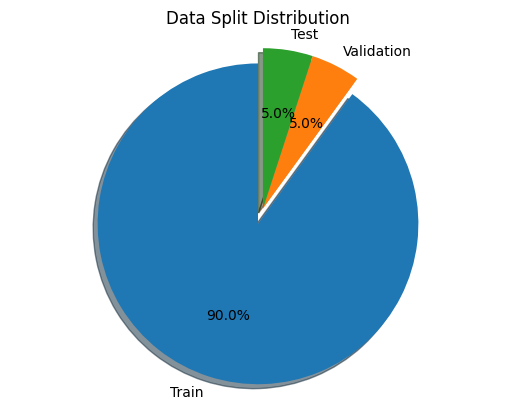

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done!


In [ ]:
# VECTORIZATION

max_tokens = 25000
sequence_length = 200

strip_chars = string.punctuation.replace("[", "").replace("]", "")

def custom_standardization(input_string):
    lowercase = tf.strings.lower(input_string)
    return tf.strings.regex_replace(lowercase, "[" + re.escape(strip_chars) + "]", "")

source_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
)

target_vectorization = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length + 1,
    standardize=custom_standardization,
)

# Shuffle and split
df = df.sample(frac=1).reset_index(drop=True)
train_size = int(len(df) * 0.90)
val_size   = int(len(df) * 0.05)

train_df = df[:train_size]
val_df   = df[train_size:train_size + val_size]
test_df  = df[train_size + val_size:]

print(f"\nSplit sizes -> Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Pie chart
labels = ['Train', 'Validation', 'Test']
sizes  = [len(train_df), len(val_df), len(test_df)]
fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=(0.1, 0, 0), labels=labels, autopct='%1.1f%%', shadow=True, startangle=90)
ax1.axis('equal')
plt.title('Data Split Distribution')
plt.show()

# Prepare text arrays
train_source_texts = train_df['source'].values
train_target_texts = ["[start] " + t + " [end]" for t in train_df['target'].values]

val_source_texts = val_df['source'].values
val_target_texts = ["[start] " + t + " [end]" for t in val_df['target'].values]

test_source_texts = test_df['source'].values
test_target_texts = ["[start] " + t + " [end]" for t in test_df['target'].values]

# Adapt on training data only
source_vectorization.adapt(train_source_texts)
target_vectorization.adapt(train_target_texts)


import pickle
from google.colab import files

pickle.dump({
    'source_config': source_vectorization.get_config(),
    'source_vocab':  source_vectorization.get_vocabulary(),
    'target_config': {
        'max_tokens': 25000,
        'output_sequence_length': 201,  # sequence_length + 1
    },
    'target_vocab':  target_vectorization.get_vocabulary(),
}, open('vectorizers.pkl', 'wb'))

files.download('vectorizers.pkl')
print("Done!")

# Encoding and decoding of the text

In [ ]:
def make_dataset(source_texts, target_texts, batch_size):
    """
    Build a tf.data pipeline.
    FIX: cache() BEFORE shuffle() so the dataset is cached in its original
    order and then shuffled each epoch — avoids freezing the shuffle.
    """
    src = source_vectorization(source_texts)
    tgt = target_vectorization(target_texts)

    enc_input = src
    dec_input = tgt[:, :-1]
    dec_target = tgt[:, 1:]

    dataset = tf.data.Dataset.from_tensor_slices((
        {"source": enc_input, "target": dec_input},
        dec_target
    ))
    return (
        dataset
        .cache()                               # cache before shuffle
        .shuffle(buffer_size=len(source_texts))
        .batch(batch_size, drop_remainder=False)
        .prefetch(tf.data.AUTOTUNE)
    )


# Positional embeddings

In [ ]:
# TRANSFORMER COMPONENTS
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, input_dim, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings = tf.keras.layers.Embedding(
            input_dim=input_dim, output_dim=output_dim, mask_zero=True)
        self.position_embeddings = tf.keras.layers.Embedding(
            input_dim=sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length
        self.input_dim = input_dim
        self.output_dim = output_dim

    def call(self, inputs):
        length = tf.shape(inputs)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        return self.token_embeddings(inputs) + self.position_embeddings(positions)

    def compute_mask(self, inputs, mask=None):
        return self.token_embeddings.compute_mask(inputs)

    def get_config(self):
        config = super().get_config()
        config.update({"input_dim": self.input_dim, "output_dim": self.output_dim,
                        "sequence_length": self.sequence_length})
        return config



In [ ]:
def shape_list(x):
    static = x.shape.as_list()
    dynamic = tf.shape(x)
    return [dynamic[i] if s is None else s for i, s in enumerate(static)]


def attention_mask(nd, ns, *, dtype):
    i = tf.range(nd)[:, None]
    j = tf.range(ns)
    return tf.cast(i >= j - ns + nd, dtype)


def mask_attn_weights(w):
    _, _, nd, ns = shape_list(w)
    b = tf.reshape(attention_mask(nd, ns, dtype=w.dtype), [1, 1, nd, ns])
    return w * b - tf.cast(1e10, w.dtype) * (1 - b)


def scaled_dot_product_attention(q, k, v, use_causal_mask=False, key_padding_mask=None):
    d_k = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(d_k)
    if use_causal_mask:
        scaled_scores = mask_attn_weights(scaled_scores)
    if key_padding_mask is not None:
        key_padding_mask = tf.cast(key_padding_mask[:, tf.newaxis, tf.newaxis, :], scaled_scores.dtype)
        scaled_scores += (key_padding_mask - 1) * 1e9
    return tf.matmul(tf.nn.softmax(scaled_scores, axis=-1), v)

 # Multihead attention

In [ ]:
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, embed_dim, h, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.h = h
        if embed_dim % h != 0:
            raise ValueError(f"embed_dim ({embed_dim}) must be divisible by num_heads ({h})")
        self.q_linear = tf.keras.layers.Dense(embed_dim)
        self.k_linear = tf.keras.layers.Dense(embed_dim)
        self.v_linear = tf.keras.layers.Dense(embed_dim)
        self.concat_linear = tf.keras.layers.Dense(embed_dim)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.h, self.embed_dim // self.h))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def concat_heads(self, x, batch_size):
        x = tf.transpose(x, perm=[0, 2, 1, 3])
        return tf.reshape(x, (batch_size, -1, self.embed_dim))

    def call(self, q, k, v, use_causal_mask=False, key_padding_mask=None):
        batch_size = tf.shape(k)[0]
        q = self.split_heads(self.q_linear(q), batch_size)
        k = self.split_heads(self.k_linear(k), batch_size)
        v = self.split_heads(self.v_linear(v), batch_size)
        attention = scaled_dot_product_attention(q, k, v, use_causal_mask, key_padding_mask)
        return self.concat_linear(self.concat_heads(attention, batch_size))

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "h": self.h})
        return config

# Transformer encoder

In [ ]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.global_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.feed_forward = tf.keras.Sequential([
            tf.keras.layers.Dense(dense_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.supports_masking = True

    def call(self, x, mask=None):
        x = self.layer_norm_1(x + self.global_self_attention(q=x, k=x, v=x, key_padding_mask=mask))
        x = self.layer_norm_2(x + self.feed_forward(x))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "dense_dim": self.dense_dim, "num_heads": self.num_heads})
        return config

# Transformer decoder

In [ ]:
class TransformerDecoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.causal_self_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.cross_attention = MultiHeadAttention(embed_dim=embed_dim, h=num_heads)
        self.feed_forward = tf.keras.Sequential([
            tf.keras.layers.Dense(dense_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layer_norm_1 = tf.keras.layers.LayerNormalization()
        self.layer_norm_2 = tf.keras.layers.LayerNormalization()
        self.layer_norm_3 = tf.keras.layers.LayerNormalization()
        self.supports_masking = True

    def call(self, x, context, mask=None, context_mask=None):
        x = self.layer_norm_1(
            x + self.causal_self_attention(q=x, k=x, v=x, use_causal_mask=True, key_padding_mask=mask))
        x = self.layer_norm_2(x + self.cross_attention(q=x, k=context, v=context, key_padding_mask=context_mask))
        x = self.layer_norm_3(x + self.feed_forward(x))
        return x

    def get_config(self):
        config = super().get_config()
        config.update({"embed_dim": self.embed_dim, "dense_dim": self.dense_dim, "num_heads": self.num_heads})
        return config


In [ ]:
def build_transformer(embed_dim, dense_dim, num_heads, dropout):
    """Factory function to build a fresh transformer model."""
    encoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="source")
    x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(encoder_inputs)
    encoder_outputs = TransformerEncoder(embed_dim, dense_dim, num_heads)(x)

    decoder_inputs = tf.keras.Input(shape=(None,), dtype="int64", name="target")
    x = PositionalEmbedding(sequence_length, max_tokens, embed_dim)(decoder_inputs)
    x = TransformerDecoder(embed_dim, dense_dim, num_heads)(x, encoder_outputs)
    x = tf.keras.layers.Dropout(dropout)(x)
    decoder_outputs = tf.keras.layers.Dense(max_tokens, activation="softmax")(x)

    return tf.keras.Model([encoder_inputs, decoder_inputs], decoder_outputs)

# Hyperparameter tuning

In [ ]:
print("# PART 2: HYPERPARAMETER TUNING")


# ------------------------------------------------------------------------------
# Custom Keras F1 metric
# ------------------------------------------------------------------------------
class TokenF1Score(tf.keras.metrics.Metric):
    def __init__(self, name='f1_score', **kwargs):
        super().__init__(name=name, **kwargs)
        self.true_positives  = self.add_weight(name='tp', initializer='zeros')
        self.false_positives = self.add_weight(name='fp', initializer='zeros')
        self.false_negatives = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_ids = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)
        y_true     = tf.cast(tf.reshape(y_true,     [-1]), tf.int32)
        y_pred_ids = tf.cast(tf.reshape(y_pred_ids, [-1]), tf.int32)
        mask       = tf.not_equal(y_true, 0)
        y_true     = tf.boolean_mask(y_true,     mask)
        y_pred_ids = tf.boolean_mask(y_pred_ids, mask)
        tp = tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred_ids), tf.float32))
        fp = tf.reduce_sum(tf.cast(tf.not_equal(y_pred_ids, y_true) &
                                   tf.not_equal(y_pred_ids, 0), tf.float32))
        fn = tf.reduce_sum(tf.cast(tf.not_equal(y_true, y_pred_ids) &
                                   tf.not_equal(y_true, 0), tf.float32))
        self.true_positives.assign_add(tp)
        self.false_positives.assign_add(fp)
        self.false_negatives.assign_add(fn)

    def result(self):
        precision = self.true_positives / (
            self.true_positives + self.false_positives + tf.keras.backend.epsilon())
        recall    = self.true_positives / (
            self.true_positives + self.false_negatives + tf.keras.backend.epsilon())
        return 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

    def reset_state(self):
        self.true_positives.assign(0.)
        self.false_positives.assign(0.)
        self.false_negatives.assign(0.)


# ------------------------------------------------------------------------------
# Dataset pipeline — lazy per-batch vectorization (avoids OOM)
# ------------------------------------------------------------------------------
def make_dataset(source_texts, target_texts, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices((source_texts, target_texts))
    dataset = dataset.shuffle(buffer_size=len(source_texts), reshuffle_each_iteration=True)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.map(
        lambda src, tgt: (
            {
                "source": source_vectorization(src),
                "target": target_vectorization(tgt)[:, :-1],
            },
            target_vectorization(tgt)[:, 1:],
        ),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    return dataset.prefetch(tf.data.AUTOTUNE)


# ------------------------------------------------------------------------------
# Hyperparameter configurations
# ------------------------------------------------------------------------------
hyperparameter_configs = [
    {'name': 'Baseline',             'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.001,  'dropout': 0.5, 'epochs': 30},
    {'name': 'Higher Learning Rate', 'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.005,  'dropout': 0.5, 'epochs': 30},
    {'name': 'Lower Learning Rate',  'embed_dim': 256, 'dense_dim': 2048, 'num_heads': 8,  'batch_size': 16, 'learning_rate': 0.0005, 'dropout': 0.5, 'epochs': 30},
    ]

all_results = []

# ------------------------------------------------------------------------------
# Training loop
# ------------------------------------------------------------------------------
for config_idx, config in enumerate(hyperparameter_configs):

    print(f"Experiment {config_idx + 1}: {config['name']}")

    for key, value in config.items():
        if key != 'name':
            print(f"  {key}: {value}")

    try:
        tf.keras.backend.clear_session()

        batch_size = config['batch_size']
        train_ds = make_dataset(train_source_texts, train_target_texts, batch_size)
        val_ds   = make_dataset(val_source_texts,   val_target_texts,   batch_size)

        transformer = build_transformer(
            config['embed_dim'], config['dense_dim'],
            config['num_heads'], config['dropout']
        )

        transformer.compile(
            optimizer=tf.keras.optimizers.Adam(
                learning_rate=config['learning_rate'], clipnorm=1.0),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy", TokenF1Score()]
        )

        checkpoint_filepath = f'/tmp/checkpoint_exp_{config_idx}.weights.h5'
        callbacks_list = [
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ModelCheckpoint(
                filepath=checkpoint_filepath, save_weights_only=True,
                monitor='val_loss', save_best_only=True, verbose=0),
        ]

        hist = transformer.fit(
            train_ds, epochs=config['epochs'],
            callbacks=callbacks_list, validation_data=val_ds, verbose=1
        )

        transformer.load_weights(checkpoint_filepath)
        eval_results = transformer.evaluate(val_ds, verbose=0)
        val_loss = eval_results[0]
        val_acc  = eval_results[1]
        val_f1   = eval_results[2]

        results = {
            'val_loss':     float(val_loss),
            'val_accuracy': float(val_acc),
            'val_f1':       float(val_f1),
            'history':      {k: [float(v) for v in vals]
                             for k, vals in hist.history.items()},
            'status': 'OK'
        }
        print(f"\n  Val Loss: {val_loss:.4f}  |  Val Acc: {val_acc:.4f}  |  Val F1: {val_f1:.4f}")

    except (tf.errors.ResourceExhaustedError, MemoryError) as e:
        print(f"\n  SKIPPED — Out of memory: {e}")
        results = {'val_loss': float('inf'), 'val_accuracy': 0.0,
                   'val_f1': 0.0, 'history': {}, 'status': 'OOM'}

    except Exception as e:
        print(f"\n  SKIPPED — Error: {e}")
        results = {'val_loss': float('inf'), 'val_accuracy': 0.0,
                   'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'}

    if config_idx == 0 and results['status'] == 'OK':
        tracker.set_baseline({
            'accuracy': results['val_accuracy'],
            'loss':     results['val_loss'],
            'f1':       results['val_f1'],
        })

    tracker.add_experiment(config, results, f"Experiment {config_idx + 1}")
    all_results.append(results)


# PART 2: HYPERPARAMETER TUNING
Experiment 1: Baseline
  embed_dim: 256
  dense_dim: 2048
  num_heads: 8
  batch_size: 16
  learning_rate: 0.001
  dropout: 0.5
  epochs: 30
Epoch 1/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 108s 103ms/step - accuracy: 0.0683 - f1_score: 0.2204 - loss: 5.2743 - val_accuracy: 0.0727 - val_f1_score: 0.3918 - val_loss: 3.3386 - learning_rate: 0.0010
Epoch 2/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 73s 86ms/step - accuracy: 0.0782 - f1_score: 0.4185 - loss: 3.1437 - val_accuracy: 0.0831 - val_f1_score: 0.4523 - val_loss: 2.8641 - learning_rate: 0.0010
Epoch 3/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 77s 91ms/step - accuracy: 0.0903 - f1_score: 0.4874 - loss: 2.5718 - val_accuracy: 0.0886 - val_f1_score: 0.4843 - val_loss: 2.6477 - learning_rate: 0.0010
Epoch 4/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 76s 89ms/step - accuracy: 0.0985 - f1_score: 0.5356 - loss: 2.2162 - val_accuracy: 0.0910 - val_f1_score: 0.4979 - val_loss: 2.5604 - learning_rate: 0.0010
Epoch 5/30
848/848 ━━━━━━━━━━━━━━━━━━━━ 7

# Pretrained model BERT

In [ ]:
# PRETRAINED MODEL:


from transformers import (
    EncoderDecoderModel,
    BertTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq,
)
from datasets import Dataset as HFDataset
import torch

print(f"\n{'='*60}")
print("Experiment 7: Pretrained — BERT Encoder-Decoder")
print(f"{'='*60}")

BERT_MODEL_NAME = "bert-base-uncased"

try:
    bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)

    # EncoderDecoderModel wraps BERT as encoder + BERT as decoder
    bert_model = EncoderDecoderModel.from_encoder_decoder_pretrained(
        BERT_MODEL_NAME, BERT_MODEL_NAME)

    # Model config — structural settings only
    bert_model.config.decoder_start_token_id = bert_tokenizer.cls_token_id
    bert_model.config.eos_token_id           = bert_tokenizer.sep_token_id
    bert_model.config.pad_token_id           = bert_tokenizer.pad_token_id
    bert_model.config.vocab_size             = bert_model.config.encoder.vocab_size
    bert_model.config.tie_word_embeddings    = False

    # Generation config — generation parameters go here, not in model.config
    bert_model.generation_config.max_length           = 128
    bert_model.generation_config.no_repeat_ngram_size = 3
    bert_model.generation_config.early_stopping       = True
    bert_model.generation_config.num_beams            = 4

    print(f"  Loaded '{BERT_MODEL_NAME}' as encoder-decoder")
    print(f"  Parameters: {bert_model.num_parameters():,}")

    # Tokenization — BERT uses [CLS] and [SEP] tokens automatically
    def tokenize_for_bert(examples, max_length=128):
        model_inputs = bert_tokenizer(
            examples['source'],
            max_length=max_length,
            truncation=True,
            padding='max_length',
        )
        labels = bert_tokenizer(
            examples['target'],
            max_length=max_length,
            truncation=True,
            padding='max_length',
        )
        # Replace pad token id with -100 so loss ignores padding
        model_inputs['labels'] = [
            [(t if t != bert_tokenizer.pad_token_id else -100) for t in lab]
            for lab in labels['input_ids']
        ]
        return model_inputs

    hf_train = HFDataset.from_dict({
        'source': list(train_source_texts),
        'target': list(train_df['target'].values)
    })
    hf_val = HFDataset.from_dict({
        'source': list(val_source_texts),
        'target': list(val_df['target'].values)
    })

    hf_train_tok = hf_train.map(
        tokenize_for_bert, batched=True, remove_columns=['source', 'target'])
    hf_val_tok   = hf_val.map(
        tokenize_for_bert, batched=True, remove_columns=['source', 'target'])

    bert_args = Seq2SeqTrainingArguments(
        output_dir='/tmp/bert_seq2seq_finetuned',
        num_train_epochs=10,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        learning_rate=5e-5,
        weight_decay=0.01,
        warmup_steps=500,
        logging_steps=50,
        report_to='none',
    )

    bert_trainer = Seq2SeqTrainer(
        model=bert_model,
        args=bert_args,
        train_dataset=hf_train_tok,
        eval_dataset=hf_val_tok,
        processing_class=bert_tokenizer,
        data_collator=DataCollatorForSeq2Seq(
            bert_tokenizer, model=bert_model, padding=True),
    )

    bert_trainer.train()
    bert_model.save_pretrained('/tmp/bert_seq2seq_finetuned_best')
    bert_tokenizer.save_pretrained('/tmp/bert_seq2seq_finetuned_best')

    bert_val_loss, bert_val_acc, bert_val_f1 = evaluate_hf_model(
        bert_model, bert_tokenizer, val_df)

    bert_results = {
        'val_loss': bert_val_loss, 'val_accuracy': bert_val_acc,
        'val_f1':   bert_val_f1,   'history': {}, 'status': 'OK'
    }
    print(f"\n  BERT  Loss: {bert_val_loss:.4f}  "
          f"Acc: {bert_val_acc:.4f}  F1: {bert_val_f1:.4f}")

except Exception as e:
    print(f"\n  SKIPPED — {e}")
    bert_results = {
        'val_loss': float('inf'), 'val_accuracy': 0.0,
        'val_f1': 0.0, 'history': {}, 'status': f'ERROR: {e}'
    }

tracker.add_experiment(
    {'name': 'Pretrained BERT Enc-Dec', 'model': BERT_MODEL_NAME,
     'batch_size': 16, 'learning_rate': 5e-5, 'dropout': 'default',
     'embed_dim': 'N/A', 'dense_dim': 'N/A', 'num_heads': 'N/A', 'epochs': 3},
    bert_results, "Pretrained BERT Encoder-Decoder"
)
all_results.append(bert_results)


# ------------------------------------------------------------------------------
# COMBINED COMPARISON TABLE — Custom Transformers + BERT
# ------------------------------------------------------------------------------
print("\n" + "="*120)
print("FULL EXPERIMENT COMPARISON — Custom Transformers vs Pretrained BERT")
print("="*120)

comparison_rows = []
for exp in tracker.experiments:
    name      = exp['config'].get('name', 'N/A')
    status    = exp['metrics'].get('status', 'OK')
    model_type = 'Pretrained' if 'Pretrained' in name else 'Custom TF'
    val_loss  = exp['metrics'].get('val_loss', float('inf'))
    val_acc   = exp['metrics'].get('val_accuracy', 0.0)
    val_f1    = exp['metrics'].get('val_f1', 0.0)

    comparison_rows.append({
        'Type':     model_type,
        'Name':     name,
        'Embed':    exp['config'].get('embed_dim', 'N/A'),
        'Batch':    exp['config'].get('batch_size', 'N/A'),
        'LR':       exp['config'].get('learning_rate', 'N/A'),
        'Epochs':   exp['config'].get('epochs', 'N/A'),
        'Val Loss': f"{val_loss:.4f}" if val_loss != float('inf') else 'inf',
        'Val Acc':  f"{val_acc:.4f}",
        'Val F1':   f"{val_f1:.4f}",
        'Status':   status if status == 'OK' else status[:30],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['_f1_sort'] = comparison_df['Val F1'].apply(
    lambda x: float(x) if x != 'inf' else -1)
comparison_df = comparison_df.sort_values(
    '_f1_sort', ascending=False).drop(columns=['_f1_sort']).reset_index(drop=True)

print(comparison_df.to_string(index=False))

best_ok = comparison_df[comparison_df['Status'] == 'OK']
if not best_ok.empty:
    best_row = best_ok.iloc[0]
    print(f"\n  Best model: {best_row['Name']}  "
          f"(Val F1: {best_row['Val F1']}  |  "
          f"Val Acc: {best_row['Val Acc']}  |  "
          f"Val Loss: {best_row['Val Loss']})")


# ------------------------------------------------------------------------------
# Bar chart — Custom vs Pretrained BERT
# ------------------------------------------------------------------------------
valid_exps = [exp for exp in tracker.experiments
              if exp['metrics'].get('status') == 'OK']

if valid_exps:
    names = [exp['config']['name'] for exp in valid_exps]
    accs  = [exp['metrics']['val_accuracy'] for exp in valid_exps]
    f1s   = [exp['metrics']['val_f1']       for exp in valid_exps]

    acc_colors = ['darkorange' if 'Pretrained' in n else 'steelblue' for n in names]
    f1_colors  = ['peru'       if 'Pretrained' in n else 'royalblue'  for n in names]

    x = np.arange(len(names))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    bars1 = axes[0].bar(x, accs, color=acc_colors, edgecolor='white')
    axes[0].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=40, ha='right', fontsize=9)
    for bar in bars1:
        axes[0].annotate(f'{bar.get_height():.3f}',
                         xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                         xytext=(0, 4), textcoords='offset points',
                         ha='center', fontsize=8)

    bars2 = axes[1].bar(x, f1s, color=f1_colors, edgecolor='white')
    axes[1].set_title('Validation F1 Score', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=40, ha='right', fontsize=9)
    for bar in bars2:
        axes[1].annotate(f'{bar.get_height():.3f}',
                         xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                         xytext=(0, 4), textcoords='offset points',
                         ha='center', fontsize=8)

    import matplotlib.patches as mpatches
    fig.legend(handles=[
        mpatches.Patch(color='steelblue',  label='Custom Transformer'),
        mpatches.Patch(color='darkorange', label='Pretrained BERT Enc-Dec'),
    ], loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.02))

    plt.suptitle('All Experiments — Custom Transformer vs Pretrained BERT',
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("\n  No successful experiments to plot.")

# saving the bert model

In [ ]:
# Load the already trained BERT and evaluate — no retraining needed
from transformers import EncoderDecoderModel, BertTokenizer

bert_tokenizer = BertTokenizer.from_pretrained('/tmp/bert_seq2seq_finetuned_best')
bert_model     = EncoderDecoderModel.from_pretrained('/tmp/bert_seq2seq_finetuned_best')

bert_val_loss, bert_val_acc, bert_val_f1 = evaluate_hf_model(
    bert_model, bert_tokenizer, val_df)

print(f"BERT  Loss: {bert_val_loss:.4f}  Acc: {bert_val_acc:.4f}  F1: {bert_val_f1:.4f}")

Loading weights:   0%|          | 0/521 [00:00<?, ?it/s]

NameError: name 'evaluate_hf_model' is not defined

In [ ]:
from google.colab import files
import shutil

# Save model and tokenizer
bert_model.save_pretrained('best_bert_model')
bert_tokenizer.save_pretrained('best_bert_model')
print("✓ Saved to best_bert_model/")

# Zip the folder so you can download it as one file
shutil.make_archive('best_bert_model', 'zip', 'best_bert_model')
print("✓ Zipped to best_bert_model.zip")

# Download
files.download('best_bert_model.zip')
# ```

# This gives you a `best_bert_model.zip` file. Unzip it and you'll get a folder like:
# ```
# best_bert_model/
# ├── config.json
# ├── generation_config.json
# ├── model.safetensors     ← the weights
# ├── tokenizer_config.json
# ├── vocab.txt
# └── special_tokens_map.json

# Comparing all the models

In [ ]:
# ------------------------------------------------------------------------------
# MODEL EVALUATION — Compare all models on a table and visualization
# Run this after all experiments are complete
# ------------------------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from transformers import EncoderDecoderModel, BertTokenizer
from sklearn.metrics import f1_score
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ------------------------------------------------------------------------------
# Step 1 — Collect all model results into a unified list
# ------------------------------------------------------------------------------

# Custom transformer results — pulled from tracker
custom_results = []
for exp in tracker.experiments:
    if exp['config'].get('embed_dim') == 'N/A':
        continue  # skip pretrained entries in tracker
    if exp['metrics'].get('status') != 'OK':
        continue
    custom_results.append({
        'Model':    exp['config']['name'],
        'Type':     'Custom Transformer',
        'Val Loss': exp['metrics']['val_loss'],
        'Val Acc':  exp['metrics']['val_accuracy'],
        'Val F1':   exp['metrics']['val_f1'],
        'Params':   'Custom',
        'Epochs':   exp['config']['epochs'],
    })

# BERT — reload from saved checkpoint and evaluate
print("Loading BERT from checkpoint...")
try:
    bert_tokenizer = BertTokenizer.from_pretrained('/tmp/bert_seq2seq_finetuned_best')
    bert_model     = EncoderDecoderModel.from_pretrained('/tmp/bert_seq2seq_finetuned_best')
    bert_model.eval().to(device)

    bert_loss, bert_acc, bert_f1 = evaluate_hf_model(
        bert_model, bert_tokenizer, val_df, num_samples=200)

    pretrained_results = [{
        'Model':    'BERT Enc-Dec',
        'Type':     'Pretrained',
        'Val Loss': bert_loss,
        'Val Acc':  bert_acc,
        'Val F1':   bert_f1,
        'Params':   '247M',
        'Epochs':   3,
    }]
    print(f"  BERT — Loss: {bert_loss:.4f}  Acc: {bert_acc:.4f}  F1: {bert_f1:.4f}")

except Exception as e:
    print(f"  Could not load BERT: {e}")
    pretrained_results = []

# Combine all results
all_model_results = custom_results + pretrained_results
results_df = pd.DataFrame(all_model_results)
results_df = results_df.sort_values('Val F1', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

# ------------------------------------------------------------------------------
# Step 2 — Print comparison table
# ------------------------------------------------------------------------------
print("\n" + "="*100)
print("MODEL COMPARISON TABLE")
print("="*100)

display_df = results_df[['Rank', 'Type', 'Model', 'Epochs', 'Params',
                          'Val Loss', 'Val Acc', 'Val F1']].copy()
display_df['Val Loss'] = display_df['Val Loss'].apply(lambda x: f"{x:.4f}")
display_df['Val Acc']  = display_df['Val Acc'].apply(lambda x: f"{x:.4f}")
display_df['Val F1']   = display_df['Val F1'].apply(lambda x: f"{x:.4f}")

print(display_df.to_string(index=False))

best = results_df.iloc[0]
print(f"\n  🏆 Best overall: {best['Model']}  "
      f"(F1: {best['Val F1']:.4f}  |  Acc: {best['Val Acc']:.4f}  |  Loss: {best['Val Loss']:.4f})")

# ------------------------------------------------------------------------------
# Step 3 — Visualization: 3-panel chart
# ------------------------------------------------------------------------------
names  = results_df['Model'].tolist()
losses = results_df['Val Loss'].tolist()
accs   = results_df['Val Acc'].tolist()
f1s    = results_df['Val F1'].tolist()
types  = results_df['Type'].tolist()

colors = ['#E8784A' if t == 'Pretrained' else '#4A7CB5' for t in types]

x     = np.arange(len(names))
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#F8F4F0')
for ax in axes:
    ax.set_facecolor('#F8F4F0')

# Panel 1 — Val Loss (lower is better)
bars1 = axes[0].bar(x, losses, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
axes[0].set_title('Validation Loss\n(lower is better)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylabel('Loss')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=35, ha='right', fontsize=8.5)
axes[0].spines[['top', 'right']].set_visible(False)
for bar in bars1:
    axes[0].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=8, fontweight='500')

# Panel 2 — Val Accuracy
bars2 = axes[1].bar(x, accs, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
axes[1].set_title('Validation Accuracy\n(higher is better)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Accuracy')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=35, ha='right', fontsize=8.5)
axes[1].spines[['top', 'right']].set_visible(False)
for bar in bars2:
    axes[1].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=8, fontweight='500')

# Panel 3 — Val F1
bars3 = axes[2].bar(x, f1s, color=colors, edgecolor='white', linewidth=0.8, width=0.6)
axes[2].set_title('Validation F1 Score\n(higher is better)', fontsize=12, fontweight='bold', pad=10)
axes[2].set_ylabel('F1 Score')
axes[2].set_xticks(x)
axes[2].set_xticklabels(names, rotation=35, ha='right', fontsize=8.5)
axes[2].spines[['top', 'right']].set_visible(False)
for bar in bars3:
    axes[2].annotate(f'{bar.get_height():.3f}',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 4), textcoords='offset points',
                     ha='center', fontsize=8, fontweight='500')

# Highlight best model with a star on the F1 panel
best_idx = f1s.index(max(f1s))
axes[2].annotate('★ Best', xy=(best_idx, max(f1s)),
                 xytext=(best_idx, max(f1s) + 0.04),
                 ha='center', fontsize=9, color='green', fontweight='bold')

# Shared legend
fig.legend(handles=[
    mpatches.Patch(color='#4A7CB5', label='Custom Transformer'),
    mpatches.Patch(color='#E8784A', label='Pretrained BERT'),
], loc='upper center', ncol=2, fontsize=10,
   bbox_to_anchor=(0.5, 1.02), framealpha=0.9)

plt.suptitle('All Models — Full Comparison (Val Loss / Accuracy / F1)',
             fontsize=14, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# Step 4 — Radar chart (optional, shows all 3 metrics per model at once)
# ------------------------------------------------------------------------------
from matplotlib.patches import FancyBboxPatch
import matplotlib.cm as cm

fig2, ax = plt.subplots(figsize=(10, 6))
fig2.patch.set_facecolor('#F8F4F0')
ax.set_facecolor('#F8F4F0')

# Normalize metrics 0-1 for radar-style dot plot
max_acc  = max(accs)  or 1
max_f1   = max(f1s)   or 1
min_loss = min(losses) or 1

norm_acc  = [a / max_acc  for a in accs]
norm_f1   = [f / max_f1   for f in f1s]
norm_loss = [min_loss / l  for l in losses]  # invert loss so higher = better

bar_w = 0.25
x2 = np.arange(len(names))

ax.bar(x2 - bar_w, norm_loss, bar_w, label='Loss (inverted, ↑ better)',
       color='#9BC4E2', edgecolor='white')
ax.bar(x2,          norm_acc,  bar_w, label='Accuracy (normalised, ↑ better)',
       color='#4A7CB5', edgecolor='white')
ax.bar(x2 + bar_w, norm_f1,   bar_w, label='F1 (normalised, ↑ better)',
       color='#E8784A', edgecolor='white')

ax.set_xticks(x2)
ax.set_xticklabels(names, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Normalised Score (1.0 = best)')
ax.set_title('Normalised Metric Comparison — All Models', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Comprehensive model evaluation

In [ ]:
from sklearn.metrics import f1_score
import torch

def evaluate_hf_model(model, tokenizer, val_df, num_samples=200,
                       max_input_length=128, max_target_length=128,
                       batch_size=16,
                       device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    model.to(device)

    sample     = val_df.sample(min(num_samples, len(val_df)), random_state=42)
    sources    = sample['source'].tolist()
    references = sample['target'].tolist()

    total_correct = 0
    total_tokens  = 0
    total_loss    = 0.0
    num_batches   = 0
    all_preds     = []
    all_labels    = []

    for i in range(0, len(sources), batch_size):
        src_batch = sources[i:i + batch_size]
        tgt_batch = references[i:i + batch_size]

        src_enc = tokenizer(
            src_batch, return_tensors='pt', padding=True,
            truncation=True, max_length=max_input_length
        ).to(device)

        tgt_enc = tokenizer(
            tgt_batch, return_tensors='pt', padding=True,
            truncation=True, max_length=max_target_length
        )
        labels = tgt_enc['input_ids'].to(device)
        labels[labels == tokenizer.pad_token_id] = -100

        with torch.no_grad():
            out   = model(**src_enc, labels=labels)
            total_loss += out.loss.item()
            num_batches += 1
            preds  = out.logits.argmax(dim=-1)
            mask   = labels != -100
            total_correct += (preds[mask] == labels[mask]).sum().item()
            total_tokens  += mask.sum().item()
            all_preds.extend(preds[mask].cpu().numpy().tolist())
            all_labels.extend(labels[mask].cpu().numpy().tolist())

    val_loss = total_loss / max(num_batches, 1)
    val_acc  = total_correct / max(total_tokens, 1)
    val_f1   = float(f1_score(
        all_labels, all_preds, average='weighted'))

    return val_loss, val_acc, val_f1

In [ ]:
# ------------------------------------------------------------------------------
# PART 4: COMPREHENSIVE MODEL EVALUATION
# ------------------------------------------------------------------------------

print("# COMPREHENSIVE MODEL EVALUATION")


class ModelEvaluator:
    """
    Handles evaluation for both custom TF transformers and pretrained HF models.
      - model=best_transformer, hf_model=None  → custom transformer branch
      - model=None, hf_model=bert_model        → HuggingFace branch
    """

    def __init__(self, model, source_vectorizer, target_vectorizer,
                 target_vocab, test_data,
                 hf_model=None, hf_tokenizer=None):
        self.model               = model
        self.hf_model            = hf_model
        self.hf_tokenizer        = hf_tokenizer
        self.source_vectorizer   = source_vectorizer
        self.target_vectorizer   = target_vectorizer
        self.target_vocab        = target_vocab
        self.target_index_lookup = dict(zip(range(len(target_vocab)), target_vocab))
        self.test_data           = test_data
        self.is_pretrained       = (hf_model is not None)

    # ------------------------------------------------------------------
    # Metric helpers
    # ------------------------------------------------------------------
    def calculate_bleu(self, reference, hypothesis):
        smoothie = SmoothingFunction().method4
        return sentence_bleu(
            [reference.split()], hypothesis.split(),
            smoothing_function=smoothie)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    # ------------------------------------------------------------------
    # Decoding — custom TF transformer
    # ------------------------------------------------------------------
    def _decode_sequence_tf(self, input_sentence):
        tokenized_input  = self.source_vectorizer([input_sentence])
        decoded_sentence = "[start]"

        for i in range(sequence_length):
            tokenized_target = self.target_vectorizer([decoded_sentence])[:, :-1]
            predictions = self.model(
                [tokenized_input, tokenized_target], training=False)
            sampled_token_index = np.argmax(predictions[0, i, :])
            sampled_token = self.target_index_lookup.get(sampled_token_index, "")
            if sampled_token == "[end]" or not sampled_token:
                break
            decoded_sentence += " " + sampled_token

        return decoded_sentence[8:].strip()

    # ------------------------------------------------------------------
    # Decoding — HuggingFace BERT encoder-decoder
    # FIX: pass decoder_start_token_id directly to generate()
    # ------------------------------------------------------------------
    def _decode_sequence_hf(self, input_sentence, max_new_tokens=128):
        device = next(self.hf_model.parameters()).device
        enc = self.hf_tokenizer(
            [input_sentence], return_tensors='pt',
            truncation=True, max_length=128, padding=True
        ).to(device)

        with torch.no_grad():
            output_ids = self.hf_model.generate(
                **enc,
                max_new_tokens=max_new_tokens,
                num_beams=4,
                early_stopping=True,
                no_repeat_ngram_size=3,
                decoder_start_token_id=self.hf_tokenizer.cls_token_id,
                eos_token_id=self.hf_tokenizer.sep_token_id,
                pad_token_id=self.hf_tokenizer.pad_token_id,
            )

        decoded = self.hf_tokenizer.decode(
            output_ids[0], skip_special_tokens=True)
        return decoded.strip()

    # ------------------------------------------------------------------
    # Unified decode_sequence
    # ------------------------------------------------------------------
    def decode_sequence(self, input_sentence):
        if self.is_pretrained:
            return self._decode_sequence_hf(input_sentence)
        else:
            return self._decode_sequence_tf(input_sentence)

    # ------------------------------------------------------------------
    # Full dataset evaluation
    # ------------------------------------------------------------------
    def evaluate_dataset(self, num_samples=100):
        print("COMPREHENSIVE EVALUATION METRICS")

        n = min(num_samples, len(self.test_data))
        sample_indices = random.sample(range(len(self.test_data)), n)

        bleu_scores, meteor_scores = [], []
        exact_matches = 0
        predictions, references, sources = [], [], []

        model_label = 'HuggingFace BERT' if self.is_pretrained else 'Custom TF'
        print(f"\n  Evaluating {n} samples ({model_label} model)...")

        for step, sample_idx in enumerate(sample_indices):
            source     = self.test_data.iloc[sample_idx]['source']
            reference  = self.test_data.iloc[sample_idx]['target']
            prediction = self.decode_sequence(source)

            bleu_scores.append(self.calculate_bleu(reference, prediction))
            meteor_scores.append(self.calculate_meteor(reference, prediction))
            predictions.append(prediction)
            references.append(reference)
            sources.append(source)

            if prediction.strip() == reference.strip():
                exact_matches += 1

            if (step + 1) % 20 == 0:
                print(f"  {step + 1}/{n} done...")

        summary = {
            'bleu':   {'mean': float(np.mean(bleu_scores)),
                       'std':  float(np.std(bleu_scores))},
            'meteor': {'mean': float(np.mean(meteor_scores)),
                       'std':  float(np.std(meteor_scores))},
            'exact_match_accuracy': exact_matches / n,
        }

        print(f"\n  Exact Match Accuracy : {summary['exact_match_accuracy']:.4f}")
        print(f"  BLEU  (mean +/- std) : {summary['bleu']['mean']:.4f}"
              f" +/- {summary['bleu']['std']:.4f}")
        print(f"  METEOR(mean +/- std) : {summary['meteor']['mean']:.4f}"
              f" +/- {summary['meteor']['std']:.4f}")

        with open('evaluation_results.json', 'w') as f:
            json.dump({
                'model_type': 'pretrained' if self.is_pretrained else 'custom',
                'summary':     summary,
                'predictions': predictions,
                'references':  references,
                'sources':     sources,
            }, f, indent=2)

        print("  Results saved to 'evaluation_results.json'")
        return summary, {
            'bleu_scores':   bleu_scores,
            'meteor_scores': meteor_scores,
            'predictions':   predictions,
            'references':    references,
        }

    # ------------------------------------------------------------------
    # Qualitative analysis
    # ------------------------------------------------------------------
    def qualitative_analysis(self, num_examples=10):
        print("QUALITATIVE ANALYSIS")

        indices = random.sample(
            range(len(self.test_data)),
            min(num_examples, len(self.test_data)))
        results = []

        for idx in indices:
            source     = self.test_data.iloc[idx]['source']
            reference  = self.test_data.iloc[idx]['target']
            prediction = self.decode_sequence(source)
            results.append({
                'source':      source,
                'reference':   reference,
                'prediction':  prediction,
                'exact_match': prediction.strip() == reference.strip(),
            })

        for i, r in enumerate(results, 1):
            match_char = "\u2713" if r['exact_match'] else "\u2717"
            bleu = self.calculate_bleu(r['reference'], r['prediction'])
            print(f"\n--- Example {i} ---")
            print(f"  Source:     {r['source']}")
            print(f"  Reference:  {r['reference']}")
            print(f"  Prediction: {r['prediction']}")
            print(f"  Match: {match_char}  |  BLEU: {bleu:.4f}")

        return results

    # ------------------------------------------------------------------
    # Visualisation
    # ------------------------------------------------------------------
    def visualize_metrics(self, metrics, model_name='Best Model'):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.patch.set_facecolor('#F8F4F0')
        for ax in axes:
            ax.set_facecolor('#F8F4F0')
            ax.spines[['top', 'right']].set_visible(False)

        axes[0].hist(metrics['bleu_scores'], bins=20,
                     color='#4A7CB5', edgecolor='white', alpha=0.85)
        axes[0].set_title('BLEU Score Distribution', fontweight='bold')
        axes[0].set_xlabel('BLEU')
        axes[0].set_ylabel('Frequency')

        axes[1].hist(metrics['meteor_scores'], bins=20,
                     color='#E8784A', edgecolor='white', alpha=0.85)
        axes[1].set_title('METEOR Score Distribution', fontweight='bold')
        axes[1].set_xlabel('METEOR')
        axes[1].set_ylabel('Frequency')

        axes[2].scatter(metrics['bleu_scores'], metrics['meteor_scores'],
                        alpha=0.5, color='#5C3520', edgecolors='white', linewidth=0.5)
        axes[2].set_title('BLEU vs METEOR', fontweight='bold')
        axes[2].set_xlabel('BLEU')
        axes[2].set_ylabel('METEOR')

        model_label = 'Pretrained BERT' if self.is_pretrained else 'Custom Transformer'
        plt.suptitle(f"Evaluation — {model_label} ({model_name})", fontsize=14,
                     fontweight='bold')
        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------------------------
# Set up evaluator — BERT branch
# ------------------------------------------------------------------------------
target_vocab = target_vectorization.get_vocabulary()

# Reload BERT if not already in memory
if 'bert_model' not in globals() or bert_model is None:
    print("Reloading BERT from checkpoint...")
    from transformers import EncoderDecoderModel, BertTokenizer
    bert_tokenizer = BertTokenizer.from_pretrained('/tmp/bert_seq2seq_finetuned_best')
    bert_model     = EncoderDecoderModel.from_pretrained('/tmp/bert_seq2seq_finetuned_best')
    print("  Loaded.")

best_model_name = 'BERT Enc-Dec'

evaluator = ModelEvaluator(
    model             = None,
    hf_model          = bert_model,
    hf_tokenizer      = bert_tokenizer,
    source_vectorizer = source_vectorization,
    target_vectorizer = target_vectorization,
    target_vocab      = target_vocab,
    test_data         = test_df,
)

summary, metrics = evaluator.evaluate_dataset(num_samples=100)
evaluator.visualize_metrics(metrics, model_name=best_model_name)
qualitative_results = evaluator.qualitative_analysis(num_examples=10)

# Interactive testing

In [ ]:
# PART 5: INTERACTIVE TESTING

print("# PART 5: INTERACTIVE TESTING")
print("\nEnter text to process (or 'quit' to exit):")

while True:
    user_input = input("\nInput: ").strip()
    if user_input.lower() in ['quit', 'exit', 'q']:
        break
    if user_input:
        try:
            output = evaluator.decode_sequence(user_input)
            print(f"Output: {output}")
        except Exception as e:
            print(f"Error: {e}")


print("PROCESSING COMPLETE")

print("  preprocessing_documentation.json  — preprocessing steps")
print("  hyperparameter_experiments.json   — experiment results")
print("  evaluation_results.json           — evaluation metrics")
print("  best_transformer_model.keras      — saved model")